# EXERCISE 1

## 1.1 Required imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

## 1.2 Load data and set parameters

In [2]:
#Load data
data = pd.read_excel("data/SX5E_Impliedvols.xlsx", header=None).values

# Parameters and grids
T = np.r_[0.0, data[0, 2:].astype(float)]          # maturities
implied_vols = data[1:, 2:].astype(float)          # implied volatility matrix
t = 0.0                                            # current time
r = 0.0                                            # risk-free rate
q = 0.0                                            # dividend rate
S0 = 100.0                                         # spot level
K = data[1:, 1].astype(float) * S0                 # absolute strike grid

num_strikes = len(K)
num_maturities = len(T)
prices = np.full((num_strikes, num_maturities), np.nan)

# Intrinsic value at t = 0 (call payoff)
prices[:, 0] = np.maximum(S0 - K, 0.0)

## 1.3 Black-Scholes call price

In [3]:

def bs_price(spot, t, sigma, strike, T_, r, q):
    """Black–Scholes formula for European call option."""
    if sigma <= 0 or T_ <= t:
        return max(spot*np.exp(-q*(T_-t)) - strike*np.exp(-r*(T_-t)), 0.0)
    d1 = (np.log(spot/strike) + (r - q + 0.5*sigma**2)*(T_-t)) / (sigma*np.sqrt(T_-t))
    d2 = d1 - sigma*np.sqrt(T_-t)
    return spot*np.exp(-q*(T_-t))*norm.cdf(d1) - strike*np.exp(-r*(T_-t))*norm.cdf(d2)

## 1.4 Price matrix from given implied vols

In [4]:
for i in range(num_strikes):
    for j in range(num_maturities - 1):
        iv = implied_vols[i, j]
        if iv > 0:
            prices[i, j + 1] = bs_price(S0, t, iv, K[i], T[j + 1], r, q)

mask_valid = (implied_vols > 0).astype(float)   # 1.0 where IV exists, else 0.0
prices[:, 1:] *= mask_valid                     # zero out prices with no IV (keep col 0)

## 1.6 Andreasen-Huge step

In [5]:
def andreasen_huge_step(valid_idx, j, v, prices, dt, dk, K):
    """Forward time step using the Andreasen–Huge finite-difference method."""
    mids = np.round((valid_idx[:-1] + valid_idx[1:]) / 2.0).astype(int)
    num_k = len(K)
    theta = np.full(num_k, np.nan)
    k = 0
    for p in range(len(mids)):
        while k < mids[p]:
            theta[k] = v[p]
            k += 1
        theta[k:] = v[-1]

    z = 0.5 * dt / (dk**2) * (theta[1:]**2)
    z = z[:-1]
    band = np.column_stack([-z, 2.0*z, -z])
    A = np.zeros((num_k, num_k))
    for m in range(num_k - 2):
        A[m + 1, m:m + 3] = band[m, :]
    A += np.eye(num_k)
    return np.linalg.solve(A, prices[:, j].copy())

def objective_factory(valid_idx, j, dt, dk, K, prices, mask_valid):
    """Build the objective function for least-squares calibration."""
    mask = mask_valid[:, j].astype(bool)
    market_prices = prices[:, j + 1].copy()

    def objective(v):
        model_prices = andreasen_huge_step(valid_idx, j, v, prices, dt, dk, K)
        diff = model_prices - market_prices
        diff[~mask] = 0.0
        return np.sum(diff**2)

    return objective

## 1.7 Calibrate each maturity layer

In [6]:
v_params = [None] * (num_maturities - 1)                 # store AH parameters v for each time step (one per maturity interval)
opts = dict(maxfun=int(1e9), maxiter=int(1e9))          

for j in range(num_maturities - 1):
    valid_idx = np.where(implied_vols[:, j] > 0)[0]      # strikes with market quotes at this maturity
    n_params = len(valid_idx)                           
    dt = T[j + 1] - T[j]                                 # time step ΔT
    dk = K[1] - K[0]                                     
    fun = objective_factory(valid_idx, j, dt, dk, K, prices, mask_valid)  # LS objective: match model prices to “market” prices
    init_guess = 0.3 * np.ones(n_params) * S0            
    bounds = [(0.0, 2*S0)] * n_params                      
    res = minimize(fun, init_guess, method="L-BFGS-B", bounds=bounds, options=opts)  # bounded quasi-Newton fit
    v_params[j] = res.x                                  
    prices[:, j + 1] = andreasen_huge_step(              # propagate prices one step forward using AH with fitted v
        valid_idx, j, v_params[j], prices, dt, dk, K
    )


## 1.8 Recompute implied vols

In [7]:
iv_interp = np.full_like(implied_vols, np.nan, dtype=float)   # allocate IV matrix

for j in range(1, num_maturities):                           # loop on maturities (skip t=0)
    for i in range(num_strikes):                              # loop on strikes
        # objective: squared price error between BS(σ) and model price at (i,j)
        f = lambda s: (bs_price(S0, t, s[0], K[i], T[j], r, q) - prices[i, j])**2
        res = minimize(f, x0=np.array([0.5]), method="Nelder-Mead")  # unconstrained 1D search
        iv_interp[i, j - 1] = abs(float(res.x[0]))            # store implied vol (abs to guard against tiny negative σ); j-1 since IV has no t=0 column


## 1.9 Extrapolation for new maturities 

In [8]:
new_T = np.array([1.0, 1.5])                                  # target maturities to extrapolate to
prices_extrap = np.full((num_strikes, len(new_T)), np.nan)    # holder for extrapolated prices

for k, Tnew in enumerate(new_T):
    j = np.where(T > Tnew)[0][0] - 1                          # index of last known maturity just before Tnew
    valid_idx = np.where(implied_vols[:, j] > 0)[0]           # strikes with quotes at that anchor maturity
    dt = Tnew - T[j]                                         
    dk = K[1] - K[0]                                          
    prices_extrap[:, k] = andreasen_huge_step(                # propagate prices forward to Tnew
        valid_idx, j, v_params[j - 1], prices, dt, dk, K      # use v calibrated on the interval ending at T[j]
    )

iv_extrap = np.full_like(prices_extrap, np.nan)               # holder for implied vols at new maturities
for k, Tnew in enumerate(new_T):
    for i in range(num_strikes):
        # minimize squared price error to back out implied vol σ at (strike i, maturity Tnew)
        f = lambda s: (bs_price(S0, t, s[0], K[i], Tnew, r, q) - prices_extrap[i, k])**2
        res = minimize(f, x0=np.array([0.5]), method="Nelder-Mead")
        iv_extrap[i, k] = abs(float(res.x[0]))                # keep σ ≥ 0 (guard against tiny negatives)


## 1.10 Plots

In [10]:
# Enable interactive 3D in Jupyter
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1.10.1 Price and IV surfaces

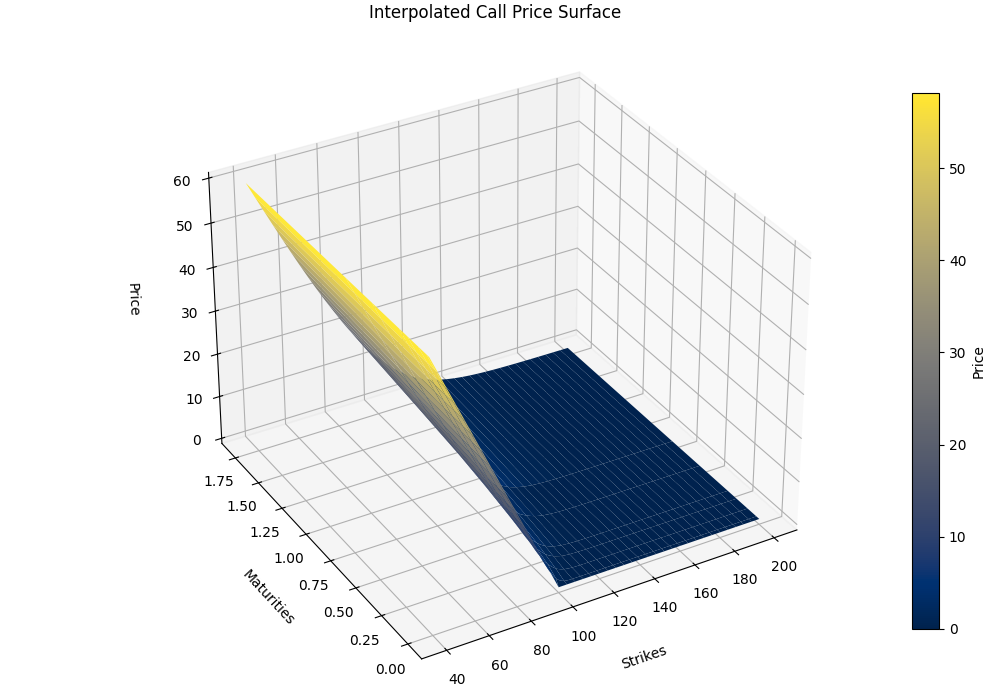

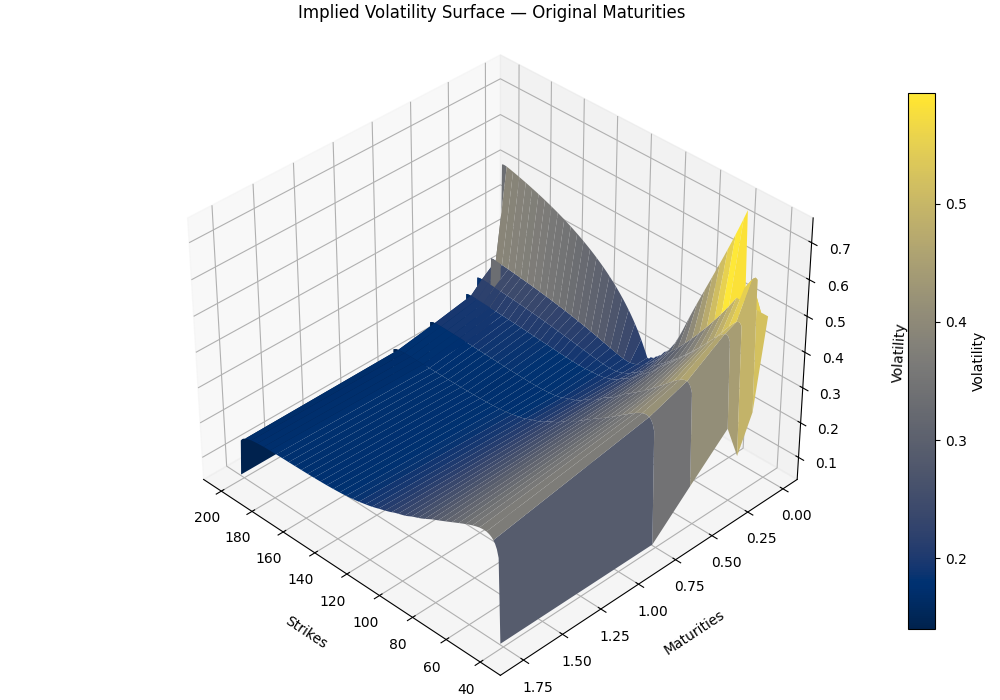

In [11]:
cmap_name = 'cividis'

# PRICE surface (X = strikes, Y = maturities)
x = np.tile(K.reshape(-1, 1), (1, num_maturities))
y = np.tile(T.reshape(1, -1), (num_strikes, 1))

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection='3d')
surf_price = ax.plot_surface(x, y, prices, cmap=cmap_name, linewidth=0, antialiased=True)
ax.set_title("Interpolated Call Price Surface")
ax.set_xlabel("Strikes",    labelpad=12)
ax.set_ylabel("Maturities", labelpad=12)
ax.set_zlabel("Price",      labelpad=16)
ax.view_init(elev=32, azim=-120)   
fig.colorbar(surf_price, ax=ax, shrink=0.8, pad=0.1, label="Price")

# IV surface (X = strikes, Y = maturities without t=0)
xv = np.tile(K.reshape(-1, 1), (1, num_maturities - 1))
yv = np.tile(T[1:].reshape(1, -1), (num_strikes, 1))

fig2 = plt.figure(figsize=(10, 7), constrained_layout=True)
ax2 = fig2.add_subplot(projection='3d')
surf_iv = ax2.plot_surface(xv, yv, iv_interp, cmap=cmap_name, linewidth=0, antialiased=True)
ax2.set_title("Implied Volatility Surface — Original Maturities")
ax2.set_xlabel("Strikes",    labelpad=12)
ax2.set_ylabel("Maturities", labelpad=12)
ax2.set_zlabel("Volatility", labelpad=18)
ax2.view_init(elev=36, azim=135) 
fig2.colorbar(surf_iv, ax=ax2, shrink=0.8, pad=0.1, label="Volatility")


## 1.10.2 Surfaces and cross sections with extrapolation

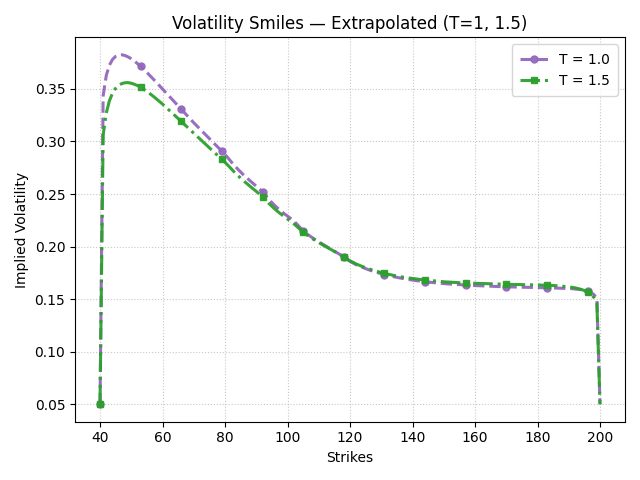

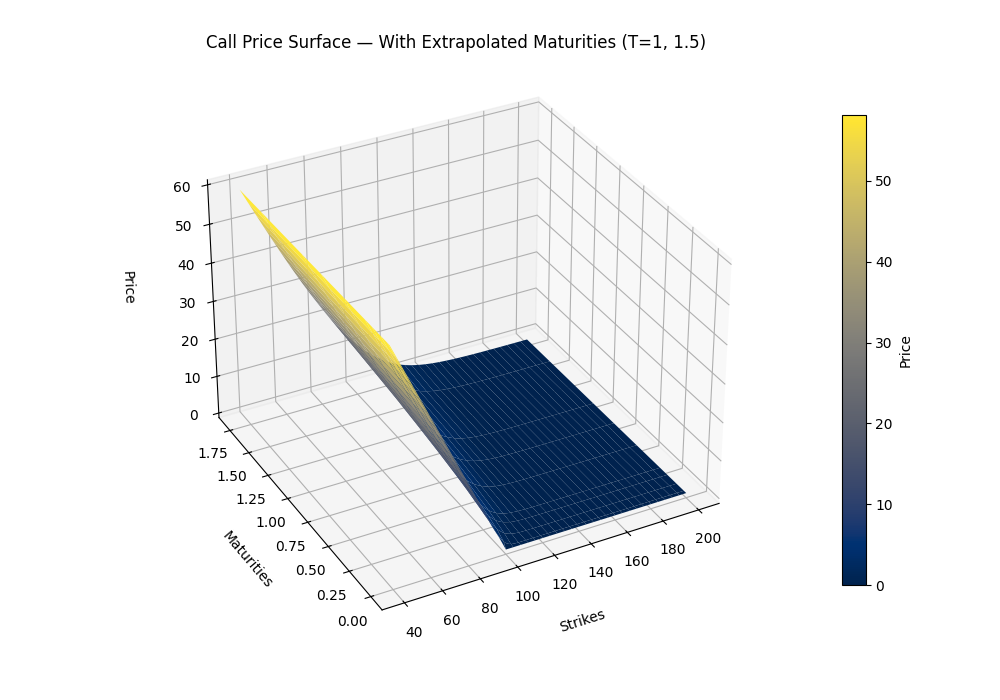

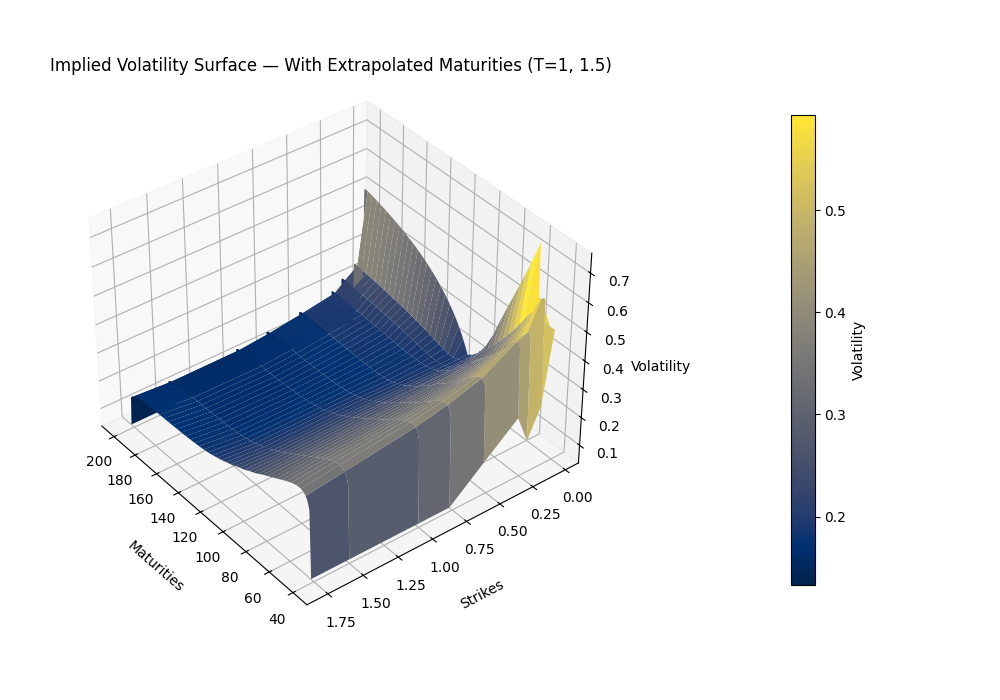

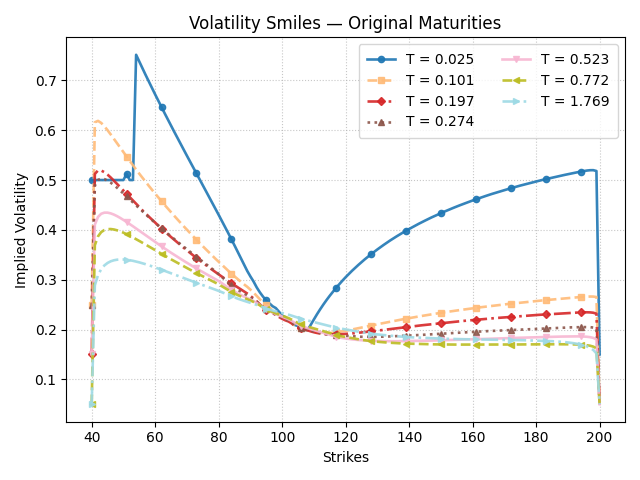

In [12]:
cmap_name = 'cividis'

allT = np.r_[T, new_T]
I = np.argsort(allT)
allT = allT[I]
allC = np.c_[prices, prices_extrap][:, I]
allInterpol_IV = np.c_[iv_interp, iv_extrap]
I_iv = np.argsort(np.r_[T[1:], new_T])
allInterpol_IV = allInterpol_IV[:, I_iv]

#SURFACE PRICES: (X=Strikes, Y=Maturities)
X = np.tile(K.reshape(-1, 1), (1, len(allT)))
Y = np.tile(allT.reshape(1, -1), (num_strikes, 1))

fig3 = plt.figure(figsize=(10, 7))
ax3 = fig3.add_subplot(projection='3d')
surf_price = ax3.plot_surface(X, Y, allC, cmap=cmap_name, linewidth=0, antialiased=True)
ax3.set_title("Call Price Surface — With Extrapolated Maturities (T=1, 1.5)")
ax3.set_xlabel("Strikes",    labelpad=12)
ax3.set_ylabel("Maturities", labelpad=12)
ax3.set_zlabel("Price",      labelpad=18)
fig3.colorbar(surf_price, ax=ax3, shrink=0.8, pad=0.1, label="Price")
fig3.subplots_adjust(left=0.06, right=0.98, bottom=0.08, top=0.92)
ax3.view_init(elev=32, azim=-118)

#SURFACE IV: (X=Strikes, Y=Maturities>0)
mats_iv_sorted = np.r_[T[1:], new_T][I_iv]
X_iv = np.tile(K.reshape(-1, 1), (1, mats_iv_sorted.size))
Y_iv = np.tile(mats_iv_sorted.reshape(1, -1), (num_strikes, 1))

fig4 = plt.figure(figsize=(10, 7))
ax4 = fig4.add_subplot(projection='3d')
surf_iv = ax4.plot_surface(X_iv, Y_iv, allInterpol_IV, cmap=cmap_name, linewidth=0, antialiased=True)
ax4.set_title("Implied Volatility Surface — With Extrapolated Maturities (T=1, 1.5)")
ax4.set_xlabel("Maturities",  labelpad=12)
ax4.set_ylabel("Strikes",     labelpad=12)
ax4.set_zlabel("Volatility",  labelpad=10)
ax4.zaxis.set_rotate_label(False)
ax4.zaxis.set_label_coords(1.08, 0.5)
cbar = fig4.colorbar(surf_iv, ax=ax4, shrink=0.8, pad=0.22)
cbar.set_label("Volatility")
fig4.subplots_adjust(left=0.06, right=0.92, bottom=0.08, top=0.92)
ax4.view_init(elev=37, azim=142)

#Cross-sections

#Volatility Smiles — Original Maturities
plt.figure()

cmap = plt.get_cmap('tab20')     
palette = [cmap(x) for x in np.linspace(0, 1, len(T)-1)]

linestyles  = ['-', '--', '-.', ':']
markers     = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*']
mark_every  = max(1, len(K)//14)

for idx, Tj in enumerate(T[1:]):
    plt.plot(
        K, iv_interp[:, idx],
        linestyle=linestyles[idx % len(linestyles)],
        marker=markers[idx % len(markers)],
        markevery=mark_every,
        markersize=4.5,
        linewidth=1.9,
        color=palette[idx],  
        alpha=0.9,
        label=f"T = {Tj:.3f}"
    )

plt.title("Volatility Smiles — Original Maturities")
plt.xlabel("Strikes")
plt.ylabel("Implied Volatility")
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)
plt.legend(ncol=2, frameon=True, fancybox=True, shadow=False, borderpad=0.6)
plt.tight_layout()


#Volatility Smiles — Extrapolated
plt.figure()

styles   = ['--', '-.']
markers  = ['o', 's']
colors   = ['tab:purple', 'tab:green']

mark_every = max(1, len(K)//12)

for idx, Tnew in enumerate(new_T):
    plt.plot(
        K, iv_extrap[:, idx],
        linestyle=styles[idx],
        marker=markers[idx],
        markevery=mark_every,
        markersize=5,
        linewidth=2.2,
        color=colors[idx],
        alpha=0.95,
        label=f"T = {Tnew}"
    )

plt.title("Volatility Smiles — Extrapolated (T=1, 1.5)")
plt.xlabel("Strikes")
plt.ylabel("Implied Volatility")
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)
plt.legend(frameon=True, fancybox=True, shadow=False, borderpad=0.6)
plt.tight_layout()

plt.show()
